In [136]:
# Standard library
import pickle

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from joblib import parallel_backend

# Scikit-learn preprocessing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Scikit-learn models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV
)
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.neighbors import NearestNeighbors

# Scikit-learn model selection and evaluation
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE

# Scikit-learn utilities
from sklearn.pipeline import Pipeline

In [137]:
def evaluate(true, predicted, display=False):
    # Calculate evaluation metrics
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, predicted)
    r2 = r2_score(true, predicted)

    # Print results
    print("Model Evaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    if display:
        # Optional: Visualize predictions vs actual values
        plt.figure(figsize=(10, 6))
        plt.scatter(true, predicted, alpha=0.5)
        plt.plot([true.min(), true.max()], [true.min(), true.max()], 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title('Actual vs Predicted Values')
        plt.tight_layout()
        plt.show()

In [138]:
def copy_plot(df, savefile=None):
    min_proj = int(df["Projected"].min())
    max_proj = int(df["Projected"].max())
    bins = np.arange(min_proj, max_proj + 2, 1)

    df["Projected_bin"] = pd.cut(df["Projected"], bins=bins, right=False, include_lowest=True)

    bin_counts_series = df.groupby("Projected_bin")["Actual"].count()
    bin_counts = bin_counts_series.values
    bin_labels_intervals = bin_counts_series.index.tolist()

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 6))

    sns.boxplot(
        x="Projected_bin", y="Actual", data=df,
        palette="Paired",
        showfliers=True
    )

    slope, intercept = np.polyfit(df['Projected'], df['Actual'], 1)
    x_line = np.linspace(df['Projected'].min(), df['Projected'].max(), 100)
    y_line = slope * x_line + intercept

    x_labels_numeric = np.array([interval.left for interval in bin_labels_intervals])
    x_line_indices = np.digitize(x_line, x_labels_numeric) - 1
    x_line_indices = np.clip(x_line_indices, 0, len(x_labels_numeric) - 1)

    # Plot the regression line
    plt.plot(x_line_indices + (x_line - x_labels_numeric[x_line_indices]) / 1.0,
             y_line,
             color="steelblue", alpha=0.7, linewidth=2)

    clean_labels = [f'{interval.left:.1f}' for interval in bin_labels_intervals]
    plt.gca().set_xticklabels(clean_labels)

    y_pos_count = 47
    for i, count in enumerate(bin_counts):
        if count > 0:
            plt.text(i, y_pos_count, str(count),
                     ha="center", va="bottom", fontsize=9, color='black') # Changed color to black

    plt.title("Projected vs Actual by Point Level", fontsize=14)
    plt.xlabel("QB Model Projected Points", fontsize=12)
    plt.ylabel("Actual Points", fontsize=12)

    plt.ylim(-1, 50)

    plt.xticks(rotation=0, ha="center", fontsize=10)

    plt.tight_layout()
    if savefile:
        plt.savefig(savefile, dpi=300, facecolor='w', edgecolor='black')
    plt.show()

In [139]:
def find_noisy_samples(X, y, n_neighbors=5, threshold=2.0):
    """
    Find samples where nearby points have very different target values
    """
    # Find nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    # For each point, check if its target differs from neighbors
    noise_scores = []
    for i in range(len(X)):
        neighbor_indices = indices[i][1:]  # Exclude self
        neighbor_targets = y[neighbor_indices]

        # Calculate how different this point's target is from neighbors
        target_std = np.std(np.append(neighbor_targets, y[i]))
        target_diff = np.abs(y[i] - np.mean(neighbor_targets))

        noise_scores.append(target_diff / (target_std + 1e-10))

    noise_scores = np.array(noise_scores)

    # Flag samples with high noise scores
    noisy_mask = noise_scores > threshold

    return noisy_mask, noise_scores

In [140]:
qb_df = pd.read_csv("../../final_qb_data.csv", index_col=0)
qb_df = qb_df.drop(['PFR_ID', 'Team', 'Opp'], axis=1)

qb_df = pd.get_dummies(qb_df)

train_df = qb_df[qb_df['YEAR'] < 2022]
validation_df = qb_df[qb_df['YEAR'] == 2022]
test_df = qb_df[qb_df['YEAR'] > 2022]

y_train = train_df['PPR'].values
X_train = train_df.drop(['PPR', 'YEAR'], axis=1).values
train_year = train_df['YEAR'].values
X_train_df = train_df.drop(['PPR', 'YEAR'], axis=1)

y_valid = validation_df['PPR'].values
X_valid = validation_df.drop(['PPR', 'YEAR'], axis=1).values
X_valid_df = validation_df.drop(['PPR', 'YEAR'], axis=1)

y_test = test_df['PPR'].values
X_test = test_df.drop(['PPR', 'YEAR'], axis=1).values
X_test_df = test_df.drop(['PPR', 'YEAR'], axis=1)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


Shape of X_train: (4146, 83)
Shape of y_train: (4146,)


In [141]:
# Neural Network (Multi-Level Perceptron Regressor)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='tanh',
    solver='adam',
    alpha=0.001,
    max_iter=5000,
    random_state=42,
    verbose=False
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_valid)

evaluate(y_valid, y_pred)

Model Evaluation Metrics:
Mean Squared Error (MSE): 62.0505
Root Mean Squared Error (RMSE): 7.8772
Mean Absolute Error (MAE): 6.1445
R² Score: 0.0462


In [142]:
# Ridge Regression
ridge = Ridge(alpha=10000.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_valid)

evaluate(y_valid, y_pred)

Model Evaluation Metrics:
Mean Squared Error (MSE): 58.9005
Root Mean Squared Error (RMSE): 7.6747
Mean Absolute Error (MAE): 6.0670
R² Score: 0.0946


In [143]:
# Use RidgeCV for cross-validated alpha selection

ridge_cv = RidgeCV(alphas=np.logspace(-2, 4, 100), cv=10)
ridge_cv.fit(X_train, y_train)
y_pred = ridge_cv.predict(X_valid)
print(f"\nRidgeCV Best Alpha: {ridge_cv.alpha_:.2f}")

evaluate(y_valid, y_pred)


RidgeCV Best Alpha: 10000.00
Model Evaluation Metrics:
Mean Squared Error (MSE): 58.9005
Root Mean Squared Error (RMSE): 7.6747
Mean Absolute Error (MAE): 6.0670
R² Score: 0.0946


In [144]:
# Lasso
lasso_cv = LassoCV(alphas=np.logspace(1, 4, 100), cv=10)
lasso_cv.fit(X_train, y_train)
y_pred = lasso_cv.predict(X_valid)
print(f"LassoCV Best Alpha: {lasso_cv.alpha_:.2f}")
print("LassoCV Results:")
evaluate(y_valid, y_pred)
print()

# ElasticNet
elastic_cv = ElasticNetCV(alphas=np.logspace(1, 4, 100), l1_ratio=[.1, .5, .7, .9, .95, .99, 1], max_iter=10000, cv=10)
elastic_cv.fit(X_train, y_train)
y_pred = elastic_cv.predict(X_valid)
print(f"ElasticNetCV Best Alpha: {elastic_cv.alpha_:.2f}")
print(f"ElasticNetCV Best L1 Ratio: {elastic_cv.l1_ratio_:.2f}")
print("ElasticNetCV Results:")
evaluate(y_valid, y_pred)

LassoCV Best Alpha: 17.48
LassoCV Results:
Model Evaluation Metrics:
Mean Squared Error (MSE): 57.6320
Root Mean Squared Error (RMSE): 7.5916
Mean Absolute Error (MAE): 5.9419
R² Score: 0.1141

ElasticNetCV Best Alpha: 151.99
ElasticNetCV Best L1 Ratio: 0.10
ElasticNetCV Results:
Model Evaluation Metrics:
Mean Squared Error (MSE): 57.5881
Root Mean Squared Error (RMSE): 7.5887
Mean Absolute Error (MAE): 5.9422
R² Score: 0.1148


In [146]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(alpha=100.0, kernel='poly', degree=2, gamma=0.01, coef0=1))
])

pipeline.fit(X_train, y_train)
y_pred_train = pipeline.predict(X_train)
y_pred_valid = pipeline.predict(X_valid)

print("\nTraining Set:")
evaluate(y_train, y_pred_train, display=False)

print("\nValidation Set:")
evaluate(y_valid, y_pred_valid, display=False)


Training Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 56.8734
Root Mean Squared Error (RMSE): 7.5414
Mean Absolute Error (MAE): 6.0277
R² Score: 0.1427

Validation Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 56.0365
Root Mean Squared Error (RMSE): 7.4858
Mean Absolute Error (MAE): 5.8570
R² Score: 0.1386


In [147]:
perm_values = permutation_importance(pipeline, X_valid, y_valid, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = perm_values.importances_mean.argsort()
print("Permutation Importances:")
for i in sorted_idx[::-1]:
    print(f"  {X_valid_df.columns[i]}: {perm_values.importances_mean[i]:.4f} +/- {perm_values.importances_std[i]:.4f}")

Permutation Importances:
  TIERS: 0.0094 +/- 0.0031
  RK: 0.0083 +/- 0.0038
  worst_rank: 0.0077 +/- 0.0027
  average_rank: 0.0068 +/- 0.0033
  SCR: 0.0058 +/- 0.0010
  best_rank: 0.0053 +/- 0.0030
  POSITION_RANK: 0.0050 +/- 0.0020
  RUN_PLAYER: 0.0047 +/- 0.0017
  Day_Sat: 0.0025 +/- 0.0013
  TACK_opponent: 0.0024 +/- 0.0016
  TA: 0.0023 +/- 0.0004
  FUM: 0.0020 +/- 0.0008
  rank_variance: 0.0018 +/- 0.0008
  RDEF: 0.0016 +/- 0.0003
  Home_Away_Home: 0.0016 +/- 0.0019
  Home_Away_Away: 0.0016 +/- 0.0019
  TTT: 0.0015 +/- 0.0004
  RUN_opponent: 0.0014 +/- 0.0007
  DEF_opponent: 0.0014 +/- 0.0007
  DPR: 0.0013 +/- 0.0004
  RBLK_opponent: 0.0011 +/- 0.0018
  PA_opponent: 0.0010 +/- 0.0005
  ecr_adp_gap: 0.0009 +/- 0.0004
  PRSH_opponent: 0.0008 +/- 0.0007
  DRP%: 0.0008 +/- 0.0005
  COV_opponent: 0.0007 +/- 0.0010
  PA: 0.0006 +/- 0.0010
  TWP%: 0.0005 +/- 0.0009
  PRSH: 0.0005 +/- 0.0001
  PF: 0.0005 +/- 0.0011
  RDEF_opponent: 0.0005 +/- 0.0002
  DRP: 0.0003 +/- 0.0004
  DB: 0.0003 +/

In [148]:
#new_features = [
#    'TIERS', 'RK', 'worst_rank', 'average_rank', 'SCR', 'best_rank',
#    'POSITION_RANK', 'RUN_PLAYER', 'TACK_opponent', 'TA', 'FUM',
#    'rank_variance', 'RDEF', 'Home_Away_Home', 'TTT', 'RUN_opponent',
#    'DEF_opponent', 'DPR', 'PA_opponent', 'PRSH_opponent', 'COV_opponent'
#]

new_features = [
    'SCR', 'RUN_PLAYER', 'TACK_opponent', 'TA', 'FUM',
    'RDEF', 'Home_Away_Home', 'TTT', 'RUN_opponent',
    'DEF_opponent', 'DPR', 'PA_opponent', 'PRSH_opponent', 'COV_opponent'
]

rank_features = ['TIERS', 'RK', 'worst_rank', 'average_rank', 'best_rank', 'POSITION_RANK', 'rank_variance']

for last_feature in rank_features:
    print(last_feature)
    features_to_use = new_features + [last_feature]
    X_train_new_tmp = X_train_df[features_to_use].values
    X_valid_new_tmp = X_valid_df[features_to_use].values

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KernelRidge(kernel='poly', degree=2, coef0=1))
    ])

    param_grid = {
        'model__alpha': [5.0, 10.0, 20.0, 35.0, 50.0, 75.0, 100.0],
        'model__gamma': [0.001, 0.01, 0.1],
    }

    #param_grid = {
    #    'model__alpha': [10.0],
    #    'model__gamma': [0.001],
    #}

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_new_tmp, y_train)
    print(grid_search.best_params_)
    print(grid_search.best_score_)
    print()

TIERS
{'model__alpha': 35.0, 'model__gamma': 0.01}
-62.959678505679335

RK
{'model__alpha': 20.0, 'model__gamma': 0.01}
-61.71086467991434

worst_rank
{'model__alpha': 35.0, 'model__gamma': 0.01}
-63.73045261722391

average_rank
{'model__alpha': 10.0, 'model__gamma': 0.01}
-61.63717796905665

best_rank
{'model__alpha': 20.0, 'model__gamma': 0.01}
-62.06784657549404

POSITION_RANK
{'model__alpha': 5.0, 'model__gamma': 0.01}
-62.52325256553739

rank_variance
{'model__alpha': 10.0, 'model__gamma': 0.001}
-65.31331336644999



In [149]:
final_features = [
    'average_rank', 'SCR', 'RUN_PLAYER', 'TACK_opponent', 'TA', 'FUM',
    'RDEF', 'Home_Away_Home', 'TTT', 'RUN_opponent', 'rank_variance',
    'DEF_opponent', 'DPR', 'PA_opponent', 'PRSH_opponent', 'COV_opponent'
]

X_train_new = X_train_df[final_features].values
X_valid_new = X_valid_df[final_features].values
X_test_new = X_test_df[final_features].values

# Remove the noisy samples
noisy_mask, noise_scores = find_noisy_samples(X_train_new, y_train, n_neighbors=10, threshold=1.5)

clean_mask = ~noisy_mask
X_train_new = X_train_new[clean_mask]
y_train_new = y_train[clean_mask]
train_year_new = train_year[clean_mask]
X_train_df_new = X_train_df[clean_mask]

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(alpha=10.0, kernel='poly', degree=2, gamma=0.01, coef0=1))
])

weights = 1 / (2022 - train_year_new + 1)

pipeline.fit(X_train_new, y_train_new)
y_pred_train = pipeline.predict(X_train_new)
y_pred_valid = pipeline.predict(X_valid_new)

print("\nTraining Set:")
evaluate(y_train_new, y_pred_train, display=False)

print("\nValidation Set:")
evaluate(y_valid, y_pred_valid, display=False)


Training Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 35.6928
Root Mean Squared Error (RMSE): 5.9743
Mean Absolute Error (MAE): 4.8345
R² Score: 0.1906

Validation Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 55.4917
Root Mean Squared Error (RMSE): 7.4493
Mean Absolute Error (MAE): 5.8525
R² Score: 0.1470


In [150]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Prepare data ---
final_features = [
    'average_rank', 'SCR', 'RUN_PLAYER', 'TACK_opponent', 'TA', 'FUM',
    'RDEF', 'Home_Away_Home', 'TTT', 'RUN_opponent', 'rank_variance',
    'DEF_opponent', 'DPR', 'PA_opponent', 'PRSH_opponent', 'COV_opponent'
]

X_train_new = X_train_df[final_features].values
X_valid_new = X_valid_df[final_features].values
X_test_new = X_test_df[final_features].values

# --- Remove noisy samples ---
noisy_mask, noise_scores = find_noisy_samples(X_train_new, y_train, n_neighbors=10, threshold=1.5)
clean_mask = ~noisy_mask
X_train_new = X_train_new[clean_mask]
y_train_new = y_train[clean_mask]
train_year_new = train_year[clean_mask]

# --- Define objective function for Optuna ---
def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    coef0 = trial.suggest_float('coef0', 0, 2)
    degree = trial.suggest_int('degree', 2, 5)
    kernel = trial.suggest_categorical('kernel', ['poly'])

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KernelRidge(
            alpha=alpha, kernel=kernel, degree=degree,
            gamma=gamma, coef0=coef0
        ))
    ])

    weights = 1 / (2022 - train_year_new + 1)
    pipeline.fit(X_train_new, y_train_new, model__sample_weight=weights)

    y_pred_valid = pipeline.predict(X_valid_new)
    mse = mean_squared_error(y_valid, y_pred_valid)
    return mse

# --- Create and optimize the study ---
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

# Let Optuna handle parallel threads
study.optimize(objective, n_trials=1000, n_jobs=16, catch=(Exception,))

# --- Best trial ---
print("\nBest Trial:")
print(study.best_trial.params)

# --- Refit best model ---
best_params = study.best_trial.params
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KernelRidge(**best_params))
])

weights = 1 / (2022 - train_year_new + 1)
best_model.fit(X_train_new, y_train_new, model__sample_weight=weights)

y_pred_train = best_model.predict(X_train_new)
y_pred_valid = best_model.predict(X_valid_new)

print("\nTraining Set:")
evaluate(y_train_new, y_pred_train, display=False)

print("\nValidation Set:")
evaluate(y_valid, y_pred_valid, display=False)

with open('qb_kernel_ridge.pkl', 'wb') as file:
    pickle.dump(best_model, file)


Best Trial:
{'alpha': 32.47408403548058, 'gamma': 0.015947370088624343, 'coef0': 0.9409497259311524, 'degree': 5, 'kernel': 'poly'}

Training Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 37.2285
Root Mean Squared Error (RMSE): 6.1015
Mean Absolute Error (MAE): 4.9040
R² Score: 0.1558

Validation Set:
Model Evaluation Metrics:
Mean Squared Error (MSE): 54.9958
Root Mean Squared Error (RMSE): 7.4159
Mean Absolute Error (MAE): 5.7865
R² Score: 0.1546


Size:  341 | Train R²: -1.3979 | Val R²: -1.0851
Size:  682 | Train R²: -0.7538 | Val R²: -0.3454
Size: 1023 | Train R²: -0.4087 | Val R²: -0.0717
Size: 1364 | Train R²: -0.2213 | Val R²: 0.0506
Size: 1706 | Train R²: -0.1104 | Val R²: 0.0755
Size: 2047 | Train R²: -0.0368 | Val R²: 0.0861
Size: 2388 | Train R²: 0.0454 | Val R²: 0.1322
Size: 2729 | Train R²: 0.1050 | Val R²: 0.1583
Size: 3070 | Train R²: 0.1514 | Val R²: 0.1284
Size: 3412 | Train R²: 0.1558 | Val R²: 0.1546


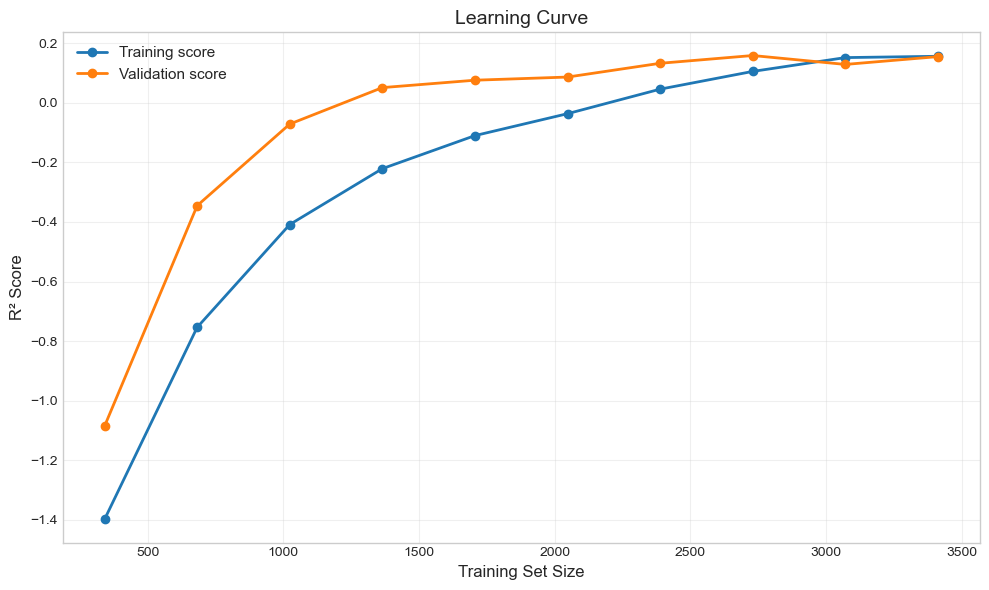

In [154]:
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores = []
val_scores = []

for size in train_sizes:
    n_samples = int(size * len(X_train_new))

    weights = 1 / (2022 - train_year_new + 1)

    # Fit on subset of training data
    best_model.fit(X_train_new[:n_samples], y_train_new[:n_samples], model__sample_weight=weights[:n_samples])

    # Score on training subset and validation set
    y_pred_train = best_model.predict(X_train_new[:n_samples])
    y_pred_val = best_model.predict(X_valid_new)

    train_r2 = r2_score(y_train_new[:n_samples], y_pred_train)
    val_r2 = r2_score(y_valid, y_pred_val)

    train_scores.append(train_r2)
    val_scores.append(val_r2)
    print(f"Size: {n_samples:4d} | Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")

# Plot
plt.figure(figsize=(10, 6))
actual_sizes = [int(s * len(X_train_new)) for s in train_sizes]

plt.plot(train_sizes*len(X_train_new), train_scores, label='Training score', marker='o', linewidth=2)
plt.plot(train_sizes*len(X_train_new), val_scores, label='Validation score', marker='o', linewidth=2)

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curve', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\thefr\AppData\Local\Temp\ipykernel_47776\2375925268.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts_series = df.groupby("Projected_bin")["Actual"].count()
C:\Users\thefr\AppData\Local\Temp\ipykernel_47776\2375925268.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\thefr\AppData\Local\Temp\ipykernel_47776\2375925268.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(clean_labels)


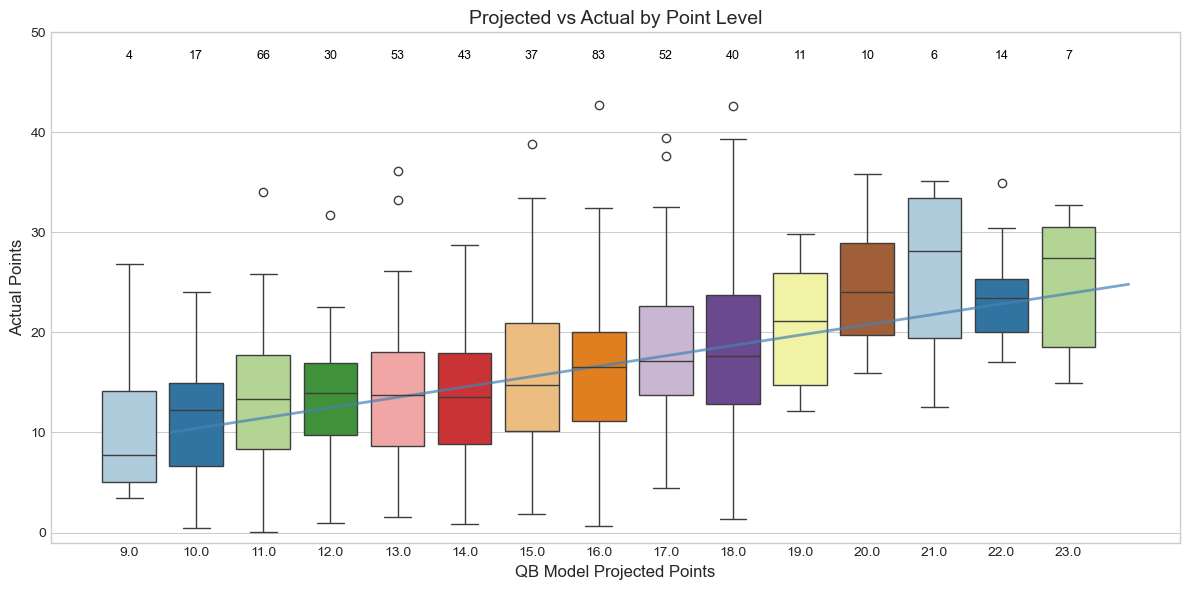

In [155]:
df = pd.DataFrame({
    "Projected": y_pred_valid,
    "Actual": y_valid
})


copy_plot(df)

C:\Users\thefr\AppData\Local\Temp\ipykernel_47776\2375925268.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts_series = df.groupby("Projected_bin")["Actual"].count()
C:\Users\thefr\AppData\Local\Temp\ipykernel_47776\2375925268.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\thefr\AppData\Local\Temp\ipykernel_47776\2375925268.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(clean_labels)


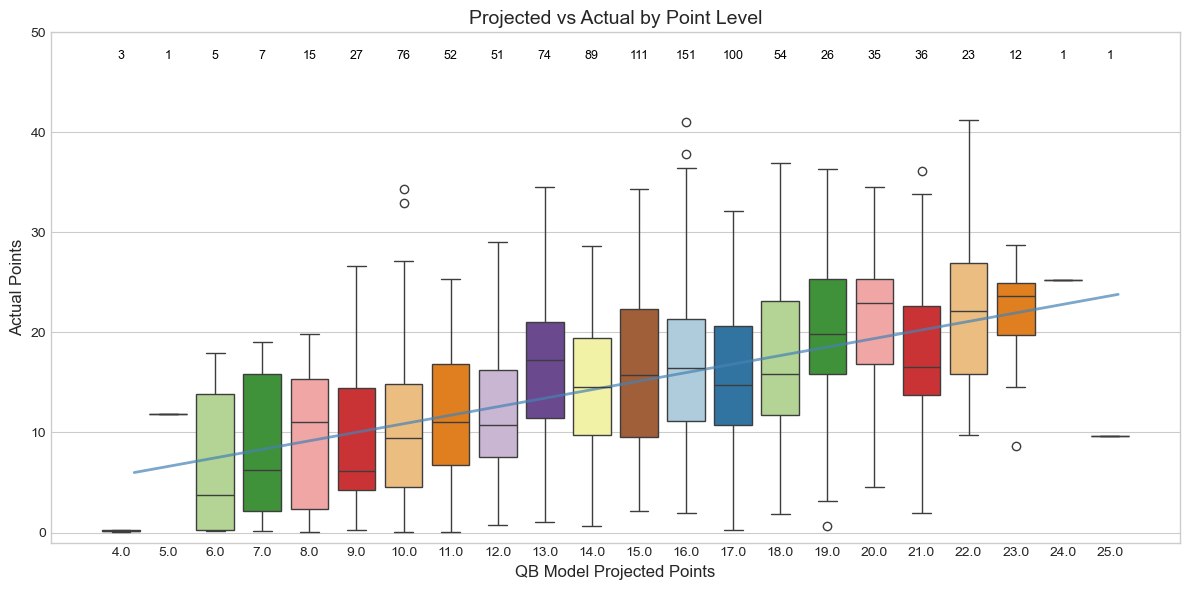

Model Evaluation Metrics:
Mean Squared Error (MSE): 59.3383
Root Mean Squared Error (RMSE): 7.7031
Mean Absolute Error (MAE): 6.2668
R² Score: 0.1331


In [156]:
df = pd.DataFrame({
    "Projected": best_model.predict(X_test_new),
    "Actual": y_test
})

copy_plot(df)

evaluate(y_test, best_model.predict(X_test_new))

In [157]:
final_features = [
    'average_rank', 'SCR', 'RUN_PLAYER', 'TACK_opponent', 'TA', 'FUM',
    'RDEF', 'Home_Away_Home', 'TTT', 'RUN_opponent', 'rank_variance',
    'DEF_opponent', 'DPR', 'PA_opponent', 'PRSH_opponent', 'COV_opponent'
]

temp_df = pd.read_csv("../../final_qb_data.csv", index_col=0)
temp_df = temp_df.drop(['Team', 'Opp'], axis=1)
temp_df = pd.get_dummies(temp_df, columns=['Home_Away', 'Day'])
#print(temp_df[temp_df['YEAR'] == 2022]['PFR_ID'].value_counts())
burrow_df = temp_df[(temp_df['YEAR'] == 2022) & (temp_df['PFR_ID'] == 'JoneDa05')]
burrow_X = burrow_df.drop(['PFR_ID', 'PPR', 'YEAR'], axis=1)[final_features].values

model = pickle.load(open('qb_kernel_ridge.pkl', 'rb'))

burrow_df['Prediction'] = model.predict(burrow_X)
print(burrow_df[['PFR_ID', 'Week', 'PPR', 'Prediction']].head(20))

        PFR_ID  Week    PPR  Prediction
26    JoneDa05    17  36.18   13.685252
118   JoneDa05     7  28.78   14.353309
237   JoneDa05    11  24.64   15.432567
390   JoneDa05     4  21.64   14.276509
436   JoneDa05    16  20.76   13.380142
531   JoneDa05    14  19.36   13.546641
638   JoneDa05    10  18.28   15.015649
757   JoneDa05    13  17.10   13.738856
885   JoneDa05     1  16.02   13.364258
1084  JoneDa05    12  14.52   13.468227
1230  JoneDa05     3  13.74   13.608627
1258  JoneDa05     6  13.52   14.252465
1331  JoneDa05     2  13.14   14.018372
1487  JoneDa05     5  12.38   13.371178
2038  JoneDa05    15   9.90   13.531537
2216  JoneDa05     8   9.04   13.645210


C:\Users\thefr\AppData\Local\Temp\ipykernel_47776\1780765078.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  burrow_df['Prediction'] = model.predict(burrow_X)
